# Microgrid Optimisation Workflow for System Design and Cost Projections.

This notebook executes the optimisation framework used to evaluate different microgrid parameters.  
Firstly the workflow imports the optimisation class, initializes the system. Then functions within the imported class read in data, setup the optimisation problem and solve it.
Additionally functions can be used to obtain different results from the initial solution allow the user to generate cost projections as required.

It should be noted that both classes consist of **class methods** as well as **instance variables** which can be used in/for various processes. The following sections of this notbook detail some examples of both being used. 

---

## 1.Import Required Libraries

The following libraries are required:

- **Optimisation class** – contains the optimisation framework developed.
- **NumPy** – used for numerical operations.
- **Matplotlib** – used for visualisation of results.

In [1]:
from IEEESESDCbackendmethodspython import Optimisation
import numpy as np
import matplotlib.pyplot as plt

## 2.Initialising the Model

The framework is implemented as a class called **Optimisation**.


An instance of this class is created and stored in the variable `case_study`.

Using this variable **class methods** as well as **instance variables** can be accessed.

---

In [2]:
case_study=Optimisation()

## 3.Data Input
Using this instance two functions are called `read_in_data` and `Solution_Setup`.

### 3.1 Model data input
`read_in_data`-Reads data from a csv and sets up required matrices and indicies used for calculations within the function `Solution_Setup`.

### 3.2 Optimisation inputs.
`Solution_Setup`-Accepts parameters to be used in developed expressions for Optimisation and uses accepted parameter in conjuction with earlier developed matrices to form expressions to be used by the optimiser for constraint modeling and to determine the final CAPEX and OPEX expression. 

The parameters it accepts are `Solution_Setup(self,project_lifetime,peak_load_demand,battery_decision,BatteryCapacity,area_limit,fuel_capacity_value,Heatrate,fuel_cost)`

The definitions for each parameter are as follows:

**:project_lifetime:** Expected lifetime of the solution. Used to determine component choice and whether replacements are required.

**:peak_load_demand:** The real powerload required to be satisfied by the solution.

**:battery_decision:** Used to determine whether battery is part of the solution.

**:BatteryCapacity:** The required capacity that must be satisfied by the choosen batteries.

**:area_limit:** The area in metres^2 that the solution cannot exceed.

**:fuel_capacity_value:** Used to set an aggregated amount of energy utlised by generator.


**:Heatrate:** The heatrate of the fuel.


**:fuel_cost:** The cost of fuel.



In [3]:
case_study.read_in_data('Data_File_4.csv')
case_study.solution_setup(20,500,0,100,5000,0.30,9,8)
case_study.Solving()
initial_list, replacement_list=case_study.component_list()

In [4]:
def results(initial_models,replacement_models):
    print ('Chosen models and quantities')
    for model in initial_models:
        print(model['model name'],model['count'])
    print('\n')
    print('Chosen replacement models and quantities')
    for model in replacement_models:
        print(model['model name'],model['count'])
    print('')
        
def cost_values(solution):
        print(f'The CAPEX for components is:$',solution.component_capex.value)
        print(f'The CAPEX for labour is: $',solution.labour_capex.value)
        print(f'Replacements cost:$',solution.replacement_cost.value)
        print(f'Operational and maintenance costs are: $',solution.om_total_cost.value)
        print(f'Fuel cost is :',solution.total_fuel_cost.value)
        print(f'Total cost:$',solution.answer.value)   
        print('\n')

    
def plots(solution):
    total_capex = solution.component_capex.value + solution.labour_capex.value
    total_om = solution.om_total_cost.value + solution.total_fuel_cost.value + solution.replacement_cost.value

    labels = ["Total CAPEX", "Total O&M"]
    values = [total_capex, total_om]

    colors = ["steelblue", "orange"]

    plt.bar(labels, values, color=colors)


    plt.ylabel("Cost ($)")
    plt.title("CAPEX vs O&M Cost Over Project Lifetime")
    plt.grid(axis='y')

    plt.show()
    print('\n')
    
def get_costs(solution):
    CAPEX=solution.component_capex.value+solution.labour_capex.value
    OPEX=solution.om_total_cost.value + solution.total_fuel_cost.value + solution.replacement_cost.value
    return CAPEX,OPEX
    
def multi_plot(CAPEX1,OPEX1,CAPEX2,OPEX2):
    labels = ["Case2", "Case3"]

    before_values = [CAPEX1,CAPEX2]
    after_values = [OPEX1,OPEX2]

    x = np.arange(len(labels))
    width = 0.35

    plt.bar(x - width/2, before_values, width, label="CAPEX", color="steelblue")
    plt.bar(x + width/2, after_values, width, label="OPEX", color="orange")

    plt.xticks(x, labels)
    plt.ylabel("Cost ($)")
    plt.title("Cost Comparison Before vs After Model Variation")
    plt.legend()
    plt.grid(axis='y')

plt.show()

def check_area_slack(case_study):
     if case_study.area_slack.value>0:
          print('Area exceeded')
          

Chosen models and quantities
Inverter A 5
Panel B 500


Chosen replacement models and quantities
Inverter A 5

The CAPEX for components is:$ 110000.0
The CAPEX for labour is: $ 100750.0
Replacements cost:$ 60750.0
Operational and maintenance costs are: $ 201500.0
Fuel cost is : 0.0
Total cost:$ 473000.0




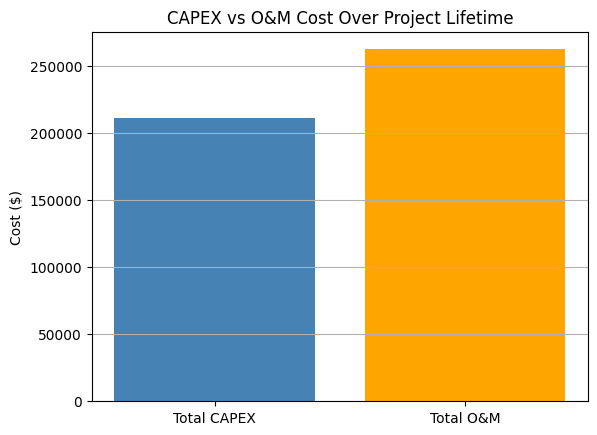

In [5]:
results(initial_list,replacement_list)
cost_values(case_study)
plots(case_study)

---


## 4.Solving and returning results 

Consequently the instance for this problem can be solved using `Solving`. The solved problem then updates the instance variables of the class which allows other functions to do their respective processes.
### 4.1 Solving
`Solving` does the actual calculations of the given problem and constraints.Done seperately to allow the other methods to append to constraints allowing solution to be repeatedly solved.

### 4.2 Returning chosen components
`Component_mix`  is used to return a list of chosen model and components as well as a list of the required replacement models.

It appends to the  lists.

`list_of_choosen_models`:The initial chosen models to satisfy the given user requests.
 
`list_of_replacements`:The required amount of replacements.



## 5.Output functions(User Defined)

The below set of user defined helper functions are used as an example of how a user can access different results from the solved solution.

These functions allow the user to :

-View the  **selected component models and quantities**

-Examine the **economic breakdown of the system**

-Generate plots for **lifecycle cost projections**.

### 5.1 Chosen component results 

The `results` function prints the appended variables lists returned by `Component_mix`.

It prints:

-The **initial** chosen model and quantities for the solution

-The **replacements** required for the chosen model and quantities 



This allows the user to see the  configuration chosen by the optimiser.

### 5.2 Cost value outputs

The `cost_values` function prints the values associated with the various expressions calculated by the optimiser.

The different cost expressions printed here are:
- **Component CAPEX** – capital cost of physical equipment
- **Labour CAPEX** – installation and construction costs
- **Replacement Costs** – cost of replacing components during the project lifetime
- **Operation and Maintenance (O&M)** – recurring maintenance expenses
- **Fuel Costs** – fuel consumption costs (for generator-based systems)

This is done by using `.value` with the chosen expression. For example:
`ComponentCAPEX` is the **instance** variable that represents the expression used to calculate the CAPEX of the chosen components. Hence `ComponentCAPEX.value` returns the value of that expression.

### 5.3 Plotting

The `plots` function outputs graphs of the optimisation results. Allowing users to view cost varation over the project lifetime.
Users can make use of the aforementioned cost expressions





### 5.4 Example

The following code shows the outputs of all 3 functions when used sequentially. (Sequential operation is not required)

## 6.Solution variation Functions

From the solved solution two additional functions can be used to vary the given solution.
These functions are:
`model_variation` and ` Generation_ban`

### 6.1 Model variation

`model_variation` accepts a case sensitive string which correlates to a specific model in the dataframe.
It is used to choose a specific model from the chosen component types after the initial solution. Constrains the quantities other models of the same type of the choice to 0. 

It also constrains the component types of the model that was not chosen to their initial values.

This function only works once a solution has been generated and can only work by selecting a model that is the same component as the models selected for the initial solution. This means you cannot constrain the solution to use a particular panel if the initial solution does not have any panels.

Since this function does not update the solution after executing `Solving` must be called.

### Use case 2.

The code below shows how the  functions are used in order to obtain different results.


Chosen models and quantities
Inverter A 5
Panel A 1525


Chosen replacement models and quantities
Inverter A 5

The CAPEX for components is:$ 822500.0
The CAPEX for labour is: $ 305750.0
Replacements cost:$ 60750.0
Operational and maintenance costs are: $ 611500.0
Fuel cost is : 0.0
Total cost:$ 1800500.0




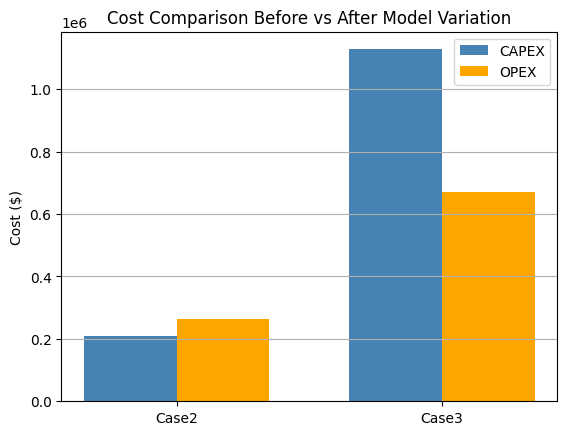

In [6]:
case1_CAPEX, case1_OPEX=get_costs(case_study)
case_study.model_variation('Panel A') 
case_study.Solving() 
initial_list, replacement_list=case_study.component_list()
results(initial_list,replacement_list)
cost_values(case_study)
case2_CAPEX,case2_OPEX=get_costs(case_study)
multi_plot(case1_CAPEX,case1_OPEX,case2_CAPEX,case2_OPEX)
case_study.clear_added_constraints()

### 6.2 Generation variation (Use case 3)

`omit_generation` accepts the index of the type of generation chosen by the user. It is used to ban a specific type of generation. The function constrains the selected type of generation to 0.

Unlike `model_variation` this function can work prior a solution has been generated.

Since this function does not update the solution after executing `Solving` must be called.


Chosen models and quantities
Turbine B 17


Chosen replacement models and quantities

The CAPEX for components is:$ 850000.0
The CAPEX for labour is: $ 5100.0
Replacements cost:$ 0.0
Operational and maintenance costs are: $ 13600.0
Fuel cost is : 0.0
Total cost:$ 868700.0




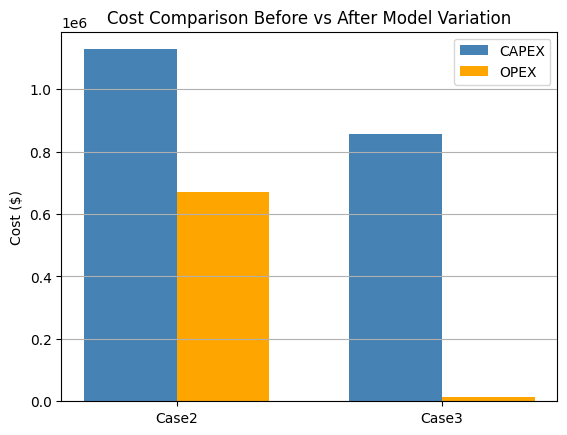

In [7]:
case2_CAPEX, case2_OPEX=get_costs(case_study)
case_study.omit_generation(case_study.PV_index)
case_study.Solving()
initial_list, replacement_list=case_study.component_list()
results(initial_list,replacement_list)
cost_values(case_study)
case3_CAPEX,case3_OPEX=get_costs(case_study)
multi_plot(case2_CAPEX,case2_OPEX,case3_CAPEX,case3_OPEX)
case_study.clear_added_constraints()

### 6.3 Area exceeding (Use case )

In the case where area of the chosen model maybe exceeded the solution will still solve thus it is up to users to check if the area slack value is exceeded.


In [8]:
case_study.Solving()
case_study.model_variation('Panel D') 
case_study.Solving()
check_area_slack(case_study)


Area exceeded
